<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH10/CH10_NB01_Activation_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Rearchitecting LLMs
## Structural techniques for efficient models

### Chapter 10: Exploring the Black Box — NB01: Single-Prompt Activation Exploration

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU T4 (also runs on CPU, only slower)

Models:
- `meta-llama/Llama-3.2-1B` — the model we instrument and run
- `Qwen/Qwen3.5-0.8B-Base` — loaded architecture-only (no weights) for a one-cell comparison in 10.1

_____
This notebook takes a single prompt through `meta-llama/Llama-3.2-1B` and opens up what happens inside: where to attach hooks to capture MLP and attention activations (10.1), what those activations look like as token x neuron heatmaps, including the GLU gate -> up -> down_proj mechanism from Chapter 5 made visible (10.2), and how a logit lens shows the model's prediction resolving layer by layer (10.3).

This is the "single prompt" half of Chapter 10. The two-prompt comparison used for bias analysis (sections 10.4-10.6) continues in `CH10_NB02_Activation_Comparison.ipynb`.

# Setting up the notebook

This section installs dependencies, imports required modules, defines the activation-capture and heatmap functions we'll use throughout the notebook, and loads the model we'll instrument.

This notebook is fully standalone: it has no dependency on the `optipfair` package. The activation-capture and heatmap-plotting logic follows the same design as `optipfair.bias` (the same library used for pruning in earlier chapters), but is reimplemented locally below so the notebook only needs `transformers`, `torch`, `numpy`, and `matplotlib`.

In [1]:
!pip install -q transformers torch matplotlib numpy

In [2]:
from typing import Dict, List, Any, Optional

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Local activation-capture and heatmap functions

This notebook is fully standalone: instead of importing `optipfair`, the activation-capture and heatmap-plotting functions it exposes in `optipfair.bias` are reimplemented locally, verbatim, right here. No behavior is changed from the library — this is purely inlining the code so the notebook has zero external dependency beyond `transformers`, `torch`, `numpy`, and `matplotlib`.

- `get_model_layers`: resolves the list of transformer decoder layers for LLaMA/Mistral/GPT-2/BERT-style architectures via `hasattr` checks.
- `register_hooks` / `remove_hooks` / `process_prompt` / `get_prompt_activations`: forward-hook based activation capture — this is what section 10.1 is about.
`visualize_prompt_layer_heatmap`).
- `visualize_prompt_heatmap` / `visualize_prompt_layer_heatmap`: the two heatmap functions used in section 10.2.

## Global configuration

In [12]:
# Model under the microscope for this whole notebook
MODEL_ID = "meta-llama/Llama-3.2-1B"

# Second model used only in 10.1, to compare .mlp submodule structure across families
SECOND_MODEL_ID = "Qwen/Qwen3.5-0.8B-Base"

# Used in 10.2 (heatmaps) and in the GLU subsection.
# Long enough to give the token x neuron heatmap several token rows to show.
PROMPT_HEATMAP = "The cat died"
#"Barcelona"#"Understanding how neural networks route information through"

# Used in 10.3 (logit lens).
# A short factual-recall prompt where the correct answer is not obvious in early layers.
PROMPT_LOGIT_LENS = "The most significant building in Barcelona is the"

# A middle transformer block: deep enough to have moved past raw token features,
# shallow enough to not yet be dominated by output-formatting behavior.
LAYER_INDEX = 8

# Visualization parameters (same style used throughout this notebook's heatmaps)
BIN_SIZE = 256
CMAP = "YlOrRd"
VMAX_PERCENTILE = 99.0

print(f"PROMPT_HEATMAP: {PROMPT_HEATMAP!r}")
print(f"PROMPT_LOGIT_LENS: {PROMPT_LOGIT_LENS!r}")

PROMPT_HEATMAP: 'The cat died'
PROMPT_LOGIT_LENS: 'The most significant building in Barcelona is the'


## Load model and tokenizer

In [13]:
print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print(f"Loading model: {MODEL_ID}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print(f"  Layers: {model.config.num_hidden_layers}")
print(f"  Hidden size: {model.config.hidden_size}")
print(f"  Intermediate size (MLP expansion): {model.config.intermediate_size}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading tokenizer: meta-llama/Llama-3.2-1B


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Loading model: meta-llama/Llama-3.2-1B


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Model loaded.
  Layers: 16
  Hidden size: 2048
  Intermediate size (MLP expansion): 8192
  Parameters: 1,235,814,400


In [14]:
second_config = AutoConfig.from_pretrained(SECOND_MODEL_ID)
second_model = AutoModelForCausalLM.from_config(second_config)

print("meta-llama/Llama-3.2-1B — layer 0:")
print(model.model.layers[0])

print(f"\n{SECOND_MODEL_ID} — layer 0:")
print(second_model.model.layers[0])

del second_model

meta-llama/Llama-3.2-1B — layer 0:
LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (k_proj): Linear(in_features=2048, out_features=512, bias=False)
    (v_proj): Linear(in_features=2048, out_features=512, bias=False)
    (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
    (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
    (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
)

Qwen/Qwen3.5-0.8B-Base — layer 0:
Qwen3_5DecoderLayer(
  (linear_attn): Qwen3_5GatedDeltaNet(
    (act): SiLUActivation()
    (conv1d): Conv1d(6144, 6144, kernel_size=(4,), stride=(1,), padding=(3,), groups=6144, bias=False)
    (norm): Qwen3

## 10.1 Capturing activations

Before we can look inside the model, we need to know exactly where to attach a "sensor." A transformer block is not one opaque unit — it is several sub-modules chained together, and each one is a legitimate, distinct capture point. The table below maps every capture point we'll use in this chapter to its real path inside a Hugging Face `LlamaForCausalLM` and to the mechanism our local `register_hooks` function uses to read it.

| Capture point | Real path | Mechanism |
|---|---|---|
| `gate_proj` | `layer.mlp.gate_proj` | forward hook |
| `up_proj` | `layer.mlp.up_proj` | forward hook |
| `down_proj_input` | input of `layer.mlp.down_proj` | forward **pre**-hook |
| MLP output (`mlp_output` / `down_proj`) | `layer.mlp` **or** `layer.mlp.down_proj` (equivalent, same tensor) | forward hook |
| `attention` | `layer.self_attn` | forward hook (output is a tuple — see below) |
| `input_norm` | `layer.input_layernorm` | forward hook |

A few things in that table are not obvious from the names alone:

- **`down_proj_input` is a pre-hook, not a hook.** A regular forward hook fires *after* a module has run and only sees its output. But what we want here is the tensor **before** `down_proj` compresses it back down — while it is still living in the expanded `intermediate_size` space (8192-wide for this model, versus the 2048-wide `hidden_size`). That tensor only exists as the *input* to `down_proj`, so we need `register_forward_pre_hook`, not `register_forward_hook`.
- **`mlp_output` and `down_proj` (output) are the same tensor.** `down_proj` is the last operation inside the MLP block — nothing transforms its output afterward before it leaves `layer.mlp`. So hooking `layer.mlp` directly or hooking `layer.mlp.down_proj`'s output gives you two different *routes* to the exact same values. We verify this below instead of just asserting it.
- **`attention` needs care.** `layer.self_attn` doesn't return a single tensor — it returns a tuple (`attn_output`, `attn_weights`, ...). A hook that blindly stores `output` would store the whole tuple. Our `register_hooks` function checks for this and keeps only `output[0]`.

In [15]:
def register_hooks(model, target_layers=None):
    """
    Attach forward hooks to capture activations from MLP and attention sub-modules.
    target_layers: list of strings (e.g. ["gate_proj", "attention"]), or None to
    capture all default points. "down_proj_input" must be requested explicitly.
    """
    activations = {}
    model._activations = activations
    handles = []

    def hook_fn(name):
        def hook(module, input, output):
            tensor = output[0] if isinstance(output, tuple) else output
            activations[name] = tensor.detach().cpu()
        return hook

    def pre_hook_fn(name):
        def hook(module, inputs):
            activations[name] = inputs[0].detach().cpu()
        return hook

    def capture(key):
      return target_layers is not None and key in target_layers

    for i, layer in enumerate(model.model.layers):

        if capture("attention") and hasattr(layer, "self_attn"):
            handles.append(
                layer.self_attn.register_forward_hook(hook_fn(f"attention_output_layer_{i}"))
            )

        if hasattr(layer, "mlp"):
            if capture("mlp_output"):
                handles.append(
                    layer.mlp.register_forward_hook(hook_fn(f"mlp_output_layer_{i}"))
                )
            if capture("gate_proj") and hasattr(layer.mlp, "gate_proj"):
                handles.append(
                    layer.mlp.gate_proj.register_forward_hook(hook_fn(f"gate_proj_layer_{i}"))
                )
            if capture("up_proj") and hasattr(layer.mlp, "up_proj"):
                handles.append(
                    layer.mlp.up_proj.register_forward_hook(hook_fn(f"up_proj_layer_{i}"))
                )
            if capture("down_proj") and hasattr(layer.mlp, "down_proj"):
                handles.append(
                    layer.mlp.down_proj.register_forward_hook(hook_fn(f"down_proj_layer_{i}"))
                )
            if capture("down_proj_input") and hasattr(layer.mlp, "down_proj"):
                handles.append(
                    layer.mlp.down_proj.register_forward_pre_hook(
                        pre_hook_fn(f"down_proj_input_layer_{i}")
                    )
                )
            if capture("act_fn") and hasattr(layer.mlp, "act_fn"):
                handles.append(
                    layer.mlp.act_fn.register_forward_hook(
                        hook_fn(f"act_fn_layer_{i}"))
                )

        if capture("input_norm") and hasattr(layer, "input_layernorm"):
            handles.append(
                layer.input_layernorm.register_forward_hook(hook_fn(f"input_norm_layer_{i}"))
            )

    return handles


def remove_hooks(handles):
    """Detach all registered hooks from the model."""
    for handle in handles:
        handle.remove()


def get_prompt_activations(model, tokenizer, prompt, target_layers=None):
    """
    Run a single prompt through the model and return a dict of captured activations.
    Keys follow the pattern "<point>_layer_<i>" (e.g. "gate_proj_layer_8").
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    handles = register_hooks(model, target_layers=target_layers)
    try:
        with torch.no_grad():
            model(**inputs)
        return {k: v.clone() for k, v in
                model._activations.items()}
    finally:
        remove_hooks(handles)
        if hasattr(model, "_activations"):
            del model._activations

In [16]:
def get_token_labels(tokenizer, prompt):
    """Tokenize a prompt and return clean labels with BOS excluded."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
    start = 1 if input_ids[0] == tokenizer.bos_token_id else 0
    labels = [
        tokenizer.convert_ids_to_tokens(int(t)).replace("▁", "").replace("Ġ", "")
        for t in input_ids[start:]
    ]
    return labels, start

def bin_neurons(tensor, bin_size):
    """Group consecutive neurons into bins, averaging within each bin."""
    n_rows, n_neurons = tensor.shape
    n_bins = n_neurons // bin_size
    trimmed = tensor[:, : n_bins * bin_size]
    return trimmed.reshape(n_rows, n_bins, bin_size).mean(axis=2)

def plot_heatmap_panel(ax, matrix, bin_size, cmap, vmax_percentile, title, y_labels=None):
    """Render one binned matrix as a heatmap panel: norm, imshow, ticks, colorbar."""
    abs_bound = float(np.percentile(np.abs(matrix), vmax_percentile))
    norm = TwoSlopeNorm(vmin=-abs_bound, vcenter=0.0, vmax=abs_bound)

    im = ax.imshow(matrix, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")

    n_bins = matrix.shape[1]
    xtick_bins = np.linspace(0, n_bins - 1, min(9, n_bins)).astype(int)
    ax.set_xticks(xtick_bins)
    ax.set_xticklabels([str(int(b * bin_size)) for b in xtick_bins], fontsize=8, rotation=30)
    ax.set_xlabel("Neuron index", fontsize=10)

    if y_labels is not None:
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=8)

    fig = ax.get_figure()
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"[-{abs_bound:.3f}, +{abs_bound:.3f}] (p{int(vmax_percentile)})", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    return im

In [17]:
# --- Verify: layer.mlp and layer.mlp.down_proj (output) are the same tensor ---
acts = get_prompt_activations(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT_HEATMAP,
    target_layers=["mlp_output", "down_proj"],
)

mlp_out = acts[f"mlp_output_layer_{LAYER_INDEX}"]
down_proj_out = acts[f"down_proj_layer_{LAYER_INDEX}"]

print(f"mlp_output shape:  {tuple(mlp_out.shape)}")
print(f"down_proj shape:   {tuple(down_proj_out.shape)}")
print(f"Identical tensor:  {torch.equal(mlp_out, down_proj_out)}")

mlp_output shape:  (1, 4, 2048)
down_proj shape:   (1, 4, 2048)
Identical tensor:  True


In [43]:
mlp_out

tensor([[[-0.0028,  0.0561, -0.0953,  ..., -0.0107, -0.0600,  0.0656],
         [ 0.0310,  0.0128,  0.0475,  ..., -0.0039,  0.0545,  0.1453],
         [ 0.0404, -0.0405, -0.0581,  ..., -0.0138,  0.0969,  0.0398],
         [ 0.1207,  0.0349, -0.0290,  ..., -0.0407,  0.1418, -0.0026]]],
       dtype=torch.float16)

In [18]:
# --- Verify: layer.self_attn returns a tuple, not a bare tensor ---
captured = {}

def _inspect_attn_output(module, inputs, output):
    captured["type"] = type(output).__name__
    captured["len"] = len(output) if isinstance(output, tuple) else None
    captured["element_0_shape"] = tuple(output[0].shape) if isinstance(output, tuple) else tuple(output.shape)

handle = model.model.layers[LAYER_INDEX].self_attn.register_forward_hook(_inspect_attn_output)
with torch.no_grad():
    model(**tokenizer(PROMPT_HEATMAP, return_tensors="pt").to(model.device))
handle.remove()

print(f"self_attn output type: {captured['type']}")
print(f"tuple length:          {captured['len']}")
print(f"element [0] shape:     {captured['element_0_shape']}  <- this is the tensor our register_hooks keeps")

self_attn output type: tuple
tuple length:          2
element [0] shape:     (1, 4, 2048)  <- this is the tensor our register_hooks keeps


### Same idea, different vocabulary

The `gate_proj` / `up_proj` / `down_proj` split isn't a Llama-specific quirk — it's the GLU MLP structure from Chapter 5, and any GLU-based model exposes the same three sub-modules. What changes between model families is the class name wrapping them, not the structure. We can see this by printing the `.mlp` submodule of one decoder layer for two models from different families, without loading either model's full weights (we only need the architecture skeleton for this comparison, which keeps this cell light enough for a free Colab T4).

In [19]:
# Llama-3.2-1B is already loaded with full weights; grab its first layer's .mlp directly.
print("meta-llama/Llama-3.2-1B — layer 0 .mlp:")
print(model.model.layers[0].mlp)

# For the second model we only need the architecture, not the trained weights,
# so we build it from its config instead of from_pretrained (no multi-GB download).
second_config = AutoConfig.from_pretrained(SECOND_MODEL_ID)
second_model_skeleton = AutoModelForCausalLM.from_config(second_config)

second_layers = second_model_skeleton.model.layers
second_mlp_layer = next(l for l in second_layers if hasattr(l, "mlp"))

print(f"\n{SECOND_MODEL_ID} — first layer with .mlp:")
print(second_mlp_layer.mlp)

del second_model_skeleton, second_layers, second_mlp_layer

meta-llama/Llama-3.2-1B — layer 0 .mlp:
LlamaMLP(
  (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
  (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
  (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
  (act_fn): SiLUActivation()
)

Qwen/Qwen3.5-0.8B-Base — first layer with .mlp:
Qwen3_5MLP(
  (gate_proj): Linear(in_features=1024, out_features=3584, bias=False)
  (up_proj): Linear(in_features=1024, out_features=3584, bias=False)
  (down_proj): Linear(in_features=3584, out_features=1024, bias=False)
  (act_fn): SiLUActivation()
)


The class names differ (`LlamaMLP` vs. `Qwen3_5MLP`) and so do the intermediate sizes, but the shape of the module is identical: a `gate_proj`, an `up_proj`, a `down_proj`, and a `SiLU`-based activation between them. The route through the object graph changes name; the GLU mechanism underneath does not.

## 10.2 Neuronal heatmap

Knowing where to hook a tensor is only half the job — a single activation tensor for `PROMPT_HEATMAP` at one layer already has `n_tokens x intermediate_size` values (17 x 8192 here). That's too many numbers to read directly. We bin neurons into groups of `BIN_SIZE` and render the result as a heatmap: color intensity encodes mean activation per bin.

We'll build two views, both using `gate_proj`:

1. **Token x neuron**, for `LAYER_INDEX` — "which neurons fire hardest for each token, at this depth?"
2. **Layer x neuron**, averaged over tokens — "how does activation intensity change as we go deeper?"

In [21]:
def visualize_prompt_heatmap(model, tokenizer, prompt, layer_key, bin_size=64,
                              cmap="RdBu_r", vmax_percentile=99.0):
    layer_prefix = layer_key.split("_layer_")[0]
    activations = get_prompt_activations(model, tokenizer, prompt, target_layers=[layer_prefix])

    token_labels, start = get_token_labels(tokenizer, prompt)
    tensor = activations[layer_key][0][start:].float().numpy()
    matrix = bin_neurons(tensor, bin_size)

    fig, ax = plt.subplots(figsize=(14, max(4, len(token_labels) * 0.45 + 2.0)))
    plot_heatmap_panel(ax, matrix, bin_size, cmap, vmax_percentile,
                        title=f"Activation Heatmap — {layer_key} | bin={bin_size}",
                        y_labels=token_labels)
    ax.set_ylabel("Token position", fontsize=11)
    plt.tight_layout()
    plt.show()

In [33]:
def visualize_prompt_layer_heatmap(model, tokenizer, prompt, layer_type, bin_size=64,
                                    cmap="RdBu_r", vmax_percentile=99.0):
    activations = get_prompt_activations(model, tokenizer, prompt, target_layers=[layer_type])
    n_layers = model.config.num_hidden_layers

    # Hooks fire in layer order (0..n_layers-1), so we can build the keys directly
    # instead of parsing and sorting them back out of the activations dict.
    rows = [
        activations[f"{layer_type}_layer_{i}"][0].float().mean(dim=0).numpy()
        for i in range(n_layers)
    ]
    matrix = bin_neurons(np.stack(rows), bin_size)

    fig, ax = plt.subplots(figsize=(14, max(4, n_layers * 0.52 + 2.5)))
    plot_heatmap_panel(ax, matrix, bin_size, cmap, vmax_percentile,
                        title=f"Layer × Neuron Heatmap — {layer_type} | bin={bin_size}",
                        y_labels=[f"L{i}" for i in range(n_layers)])
    ax.set_ylabel("Layer", fontsize=11)
    plt.tight_layout()
    plt.show()

In [34]:
# Capture once so we can inspect shapes directly, in addition to the plots below.
heatmap_acts = get_prompt_activations(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT_HEATMAP,
    target_layers=["gate_proj", "up_proj", "down_proj_input"],
)

n_tokens = tokenizer(PROMPT_HEATMAP, return_tensors="pt")["input_ids"].shape[1]
print(f"Prompt: {PROMPT_HEATMAP!r}")
print(f"Tokens (incl. BOS): {n_tokens}")
print(f"\nCaptured {len(heatmap_acts)} tensors, e.g.:")
for key in [f"gate_proj_layer_{LAYER_INDEX}", f"up_proj_layer_{LAYER_INDEX}", f"down_proj_input_layer_{LAYER_INDEX}"]:
    t = heatmap_acts[key]
    print(f"  {key}: shape={tuple(t.shape)}")

Prompt: 'The cat died'
Tokens (incl. BOS): 4

Captured 48 tensors, e.g.:
  gate_proj_layer_8: shape=(1, 4, 8192)
  up_proj_layer_8: shape=(1, 4, 8192)
  down_proj_input_layer_8: shape=(1, 4, 8192)


### Token x neuron, one layer

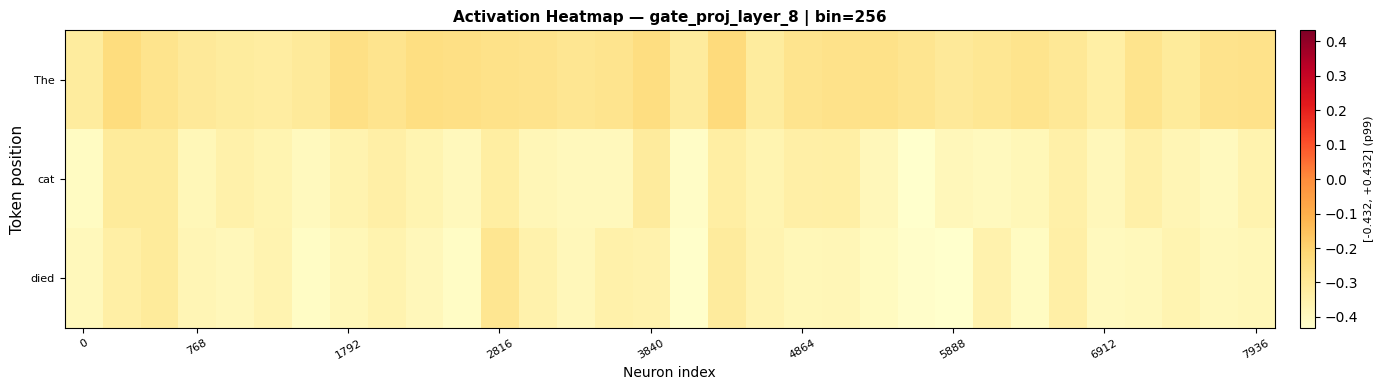

In [35]:
visualize_prompt_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT_HEATMAP,
    layer_key=f"gate_proj_layer_{LAYER_INDEX}",
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
)

Row `T0` — the `<|begin_of_text|>` token — stands out as a uniformly bright band across almost every neuron bin. This is not a bug in the capture code: it is the well-documented "attention sink" / "massive activations" behavior of the BOS token in Llama-family models, where the first position accumulates unusually large, broadly-shared activations that the rest of the sequence doesn't need to attend past. It's exactly the kind of surprise this chapter is built around — the black box doing something structurally consistent that isn't visible from the architecture diagram alone.

### Layer x neuron, averaged over tokens

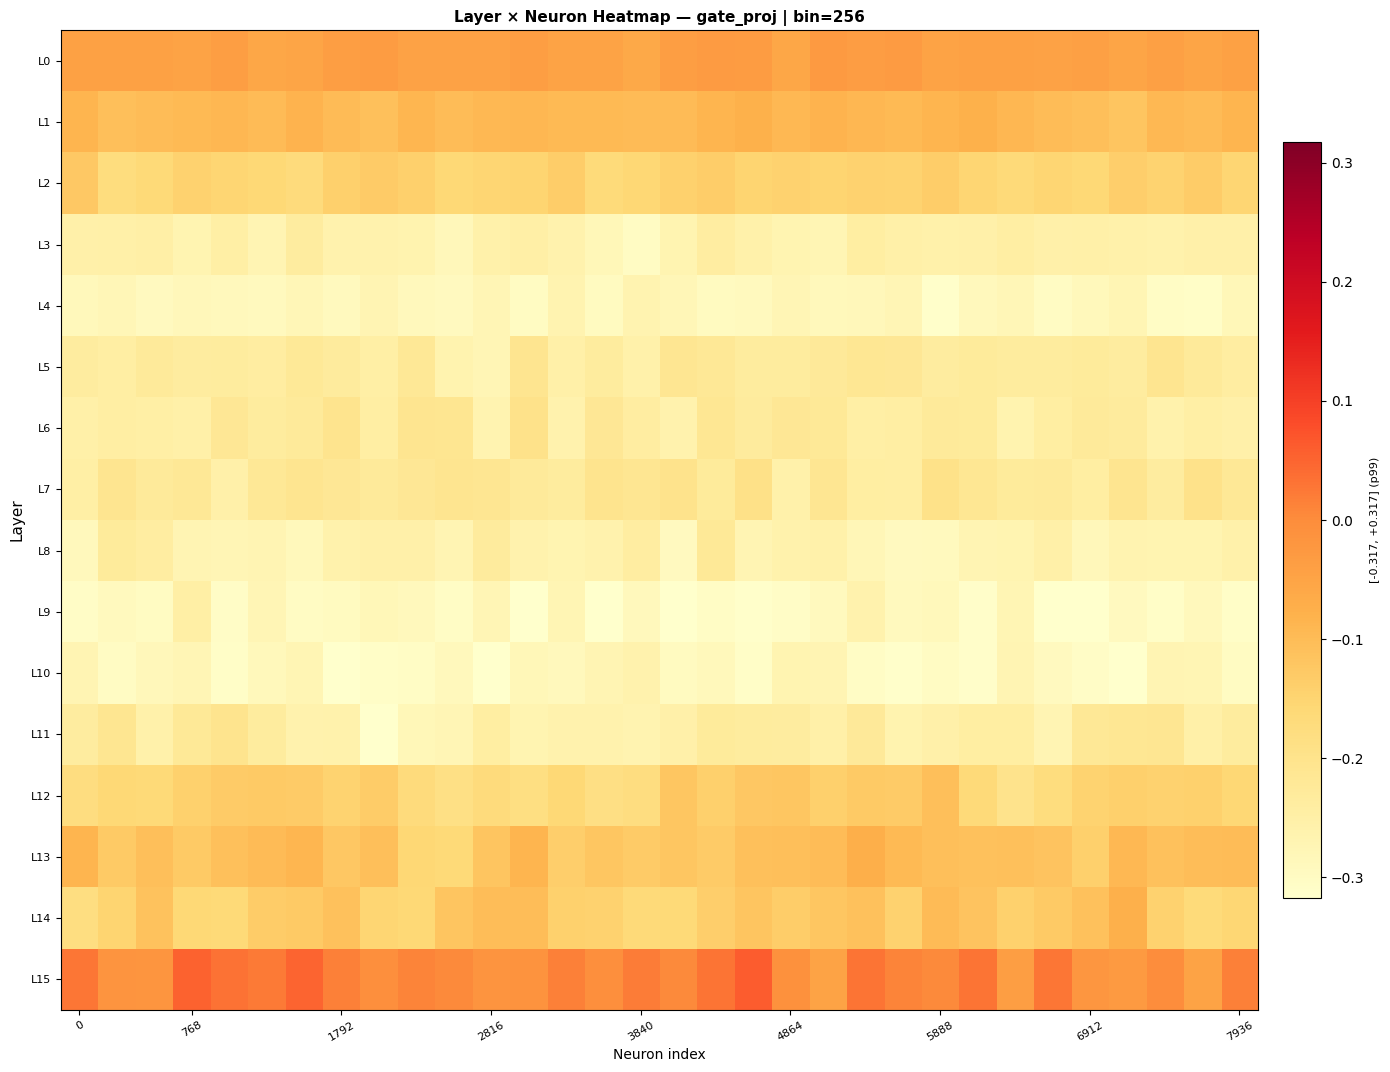

In [36]:
visualize_prompt_layer_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT_HEATMAP,
    layer_type="gate_proj",
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
)

Averaged over all tokens, `gate_proj` activation intensity isn't flat across depth: it's higher in the first couple of layers (still carrying that BOS effect), fades through the middle of the network, and rises again in the last layer or two as the model shifts from building representations to preparing an output distribution.

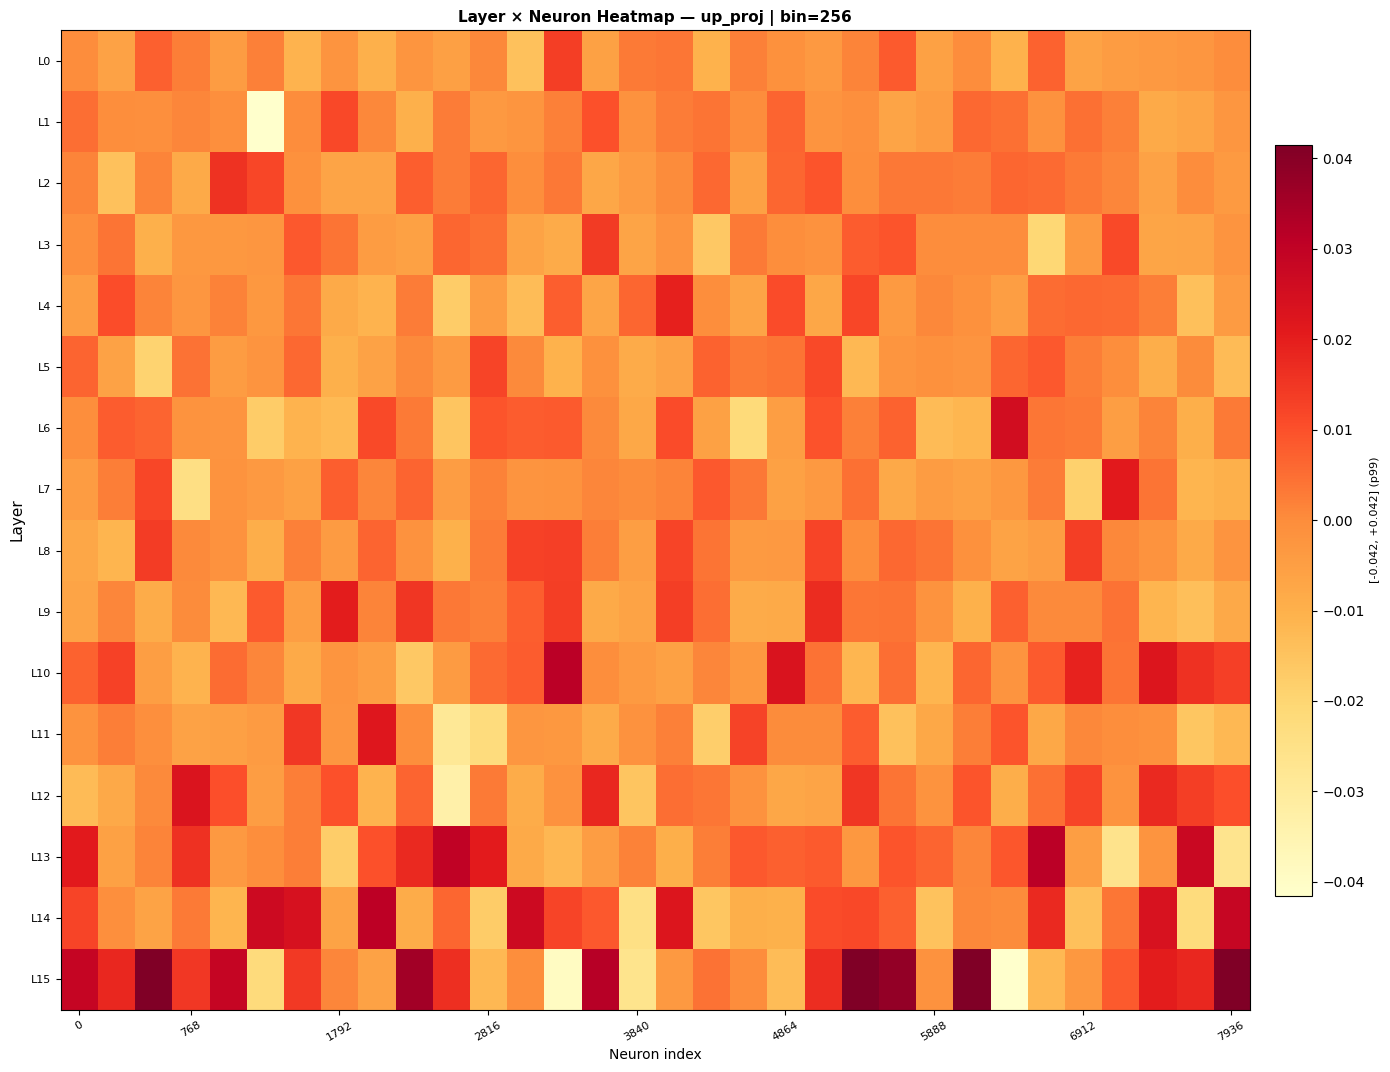

In [27]:
visualize_prompt_layer_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT_HEATMAP,
    layer_type="up_proj",
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
)

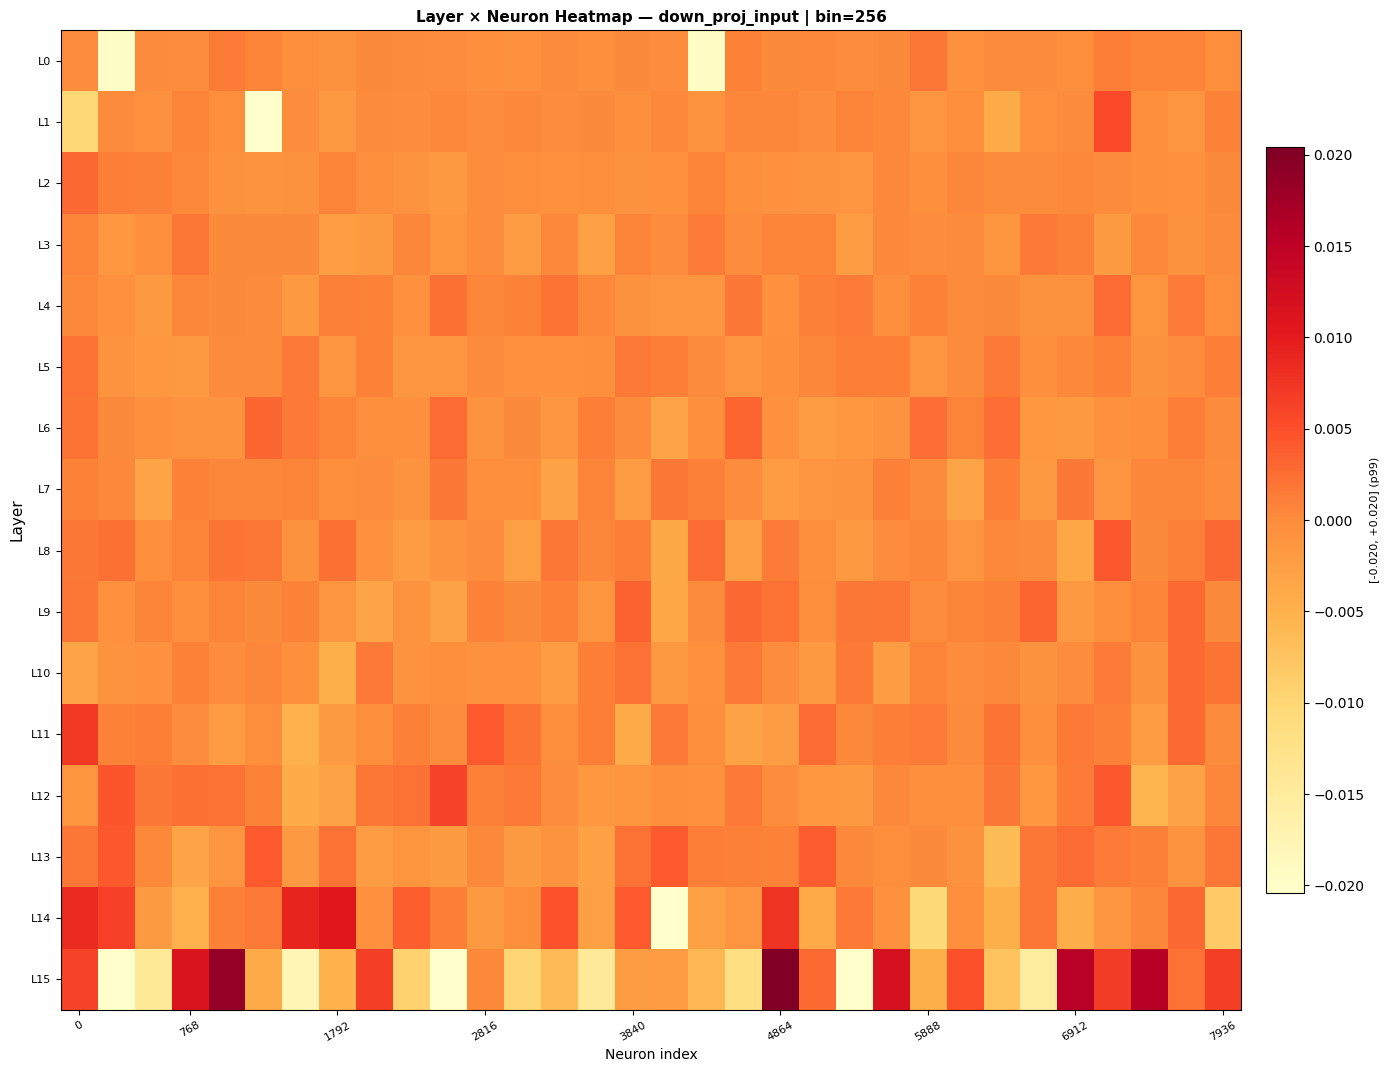

In [28]:
visualize_prompt_layer_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT_HEATMAP,
    layer_type="down_proj_input",
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
)

### GLU in action

Chapter 5 introduced the GLU MLP as math: `down_proj(SiLU(gate_proj(x)) * up_proj(x))`. The heatmap above is the `gate_proj` half of that expression, on its own, for one layer — the "single panel, one projection" view. Now let's put it side by side with `up_proj` and `down_proj_input` (the tensor produced by `SiLU(gate) * up`, the input `down_proj` actually receives) to see the gating mechanism act on real activations for the same prompt and layer.

In [40]:
def visualize_glu_three_panel(model, tokenizer, prompt, layer_index, bin_size=64,
                               cmap="YlOrRd", vmax_percentile=99.0):
    keys = ["act_fn", "up_proj", "down_proj_input"]
    titles = ["act_fn\n(SiLU(gate))", "up_proj", "down_proj_input\n(SiLU(gate) x up)"]
    activations = get_prompt_activations(model, tokenizer, prompt, target_layers=keys)

    token_labels, start = get_token_labels(tokenizer, prompt)

    fig, axes = plt.subplots(1, 3, figsize=(19, max(4, len(token_labels) * 0.4 + 2)), sharey=True)
    for ax, key, title in zip(axes, keys, titles):
        tensor = activations[f"{key}_layer_{layer_index}"][0][start:].float().numpy()
        matrix = bin_neurons(tensor, bin_size)
        plot_heatmap_panel(ax, matrix, bin_size, cmap, vmax_percentile, title=title)

    axes[0].set_yticks(range(len(token_labels)))
    axes[0].set_yticklabels(token_labels, fontsize=8)
    axes[0].set_ylabel("Token position", fontsize=10)
    fig.suptitle(f"GLU in action -- layer {layer_index}: gate -> up -> down_proj_input",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

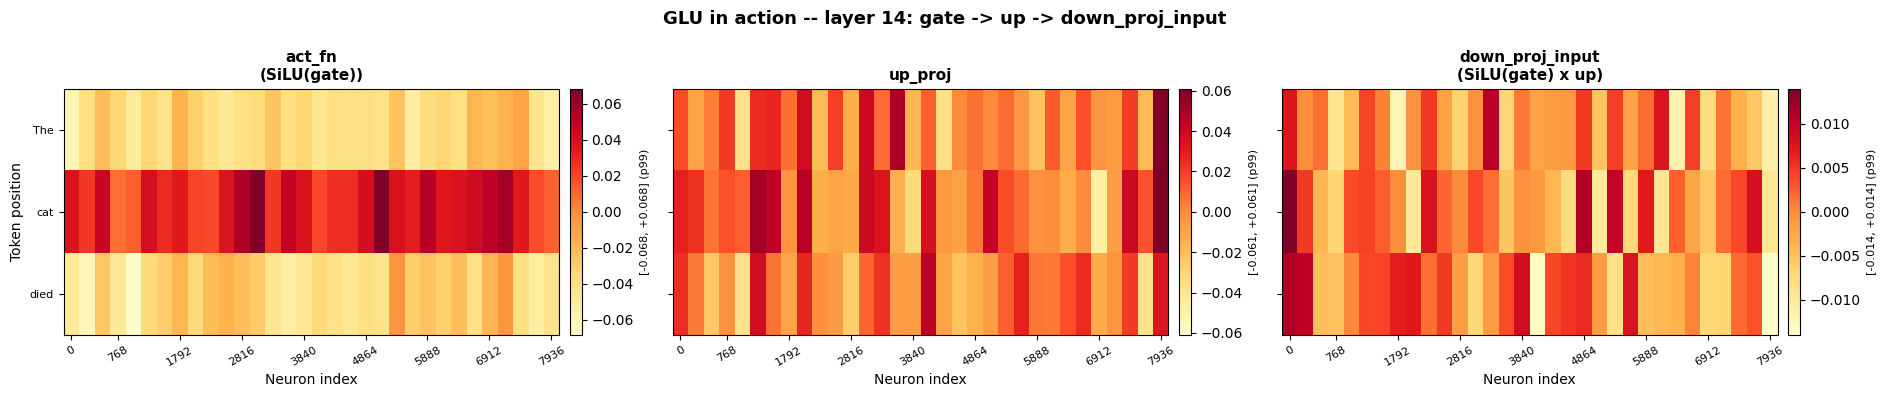

In [41]:
visualize_glu_three_panel(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT_HEATMAP,
    layer_index=14,
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
)

The leftmost panel is the same `gate_proj` pattern shown on its own above — dominated by the BOS row, otherwise fairly uniform across neuron bins at this layer. `up_proj` (middle) is where the real per-neuron structure lives: several neuron bins are consistently more active than others across almost every token, a signature of specific neurons specializing for this input. `down_proj_input` (right) — the actual signal that reaches `down_proj` — inherits that same column structure from `up_proj`, reshaped by the gate: this is `SiLU(gate) * up` visibly filtering, not just multiplying, the up-projection's output before it gets compressed back to `hidden_size`. Three panels, one prompt, one layer — the same figure layout returns in Chapter 11 for the bias-path heatmap.

## 10.3 Logit lens

Every capture point in 10.1 and 10.2 needed a hook: we had to reach *inside* a sub-module to see an intermediate tensor. The logit lens works differently. It taps the residual stream — the running sum of embeddings, attention, and MLP outputs that flows *between* transformer blocks — which Hugging Face already exposes for us when we call the model with `output_hidden_states=True`. No manual hook required: sometimes the signal you want needs a hook, sometimes the framework already hands it to you.

The idea: at every layer, take the hidden state, run it through the model's **final** norm and `lm_head` early — as if that layer's output were already the last one — and read off what token it would predict. Early layers weren't trained to be decoded this way, so the result is a rough approximation, not the model's real intermediate belief. But in practice it tracks a real trend: the prediction usually starts generic and sharpens into the correct answer over the last several layers.

In [30]:
inputs = tokenizer(PROMPT_LOGIT_LENS, return_tensors="pt").to(model.device)
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

hidden_states = outputs.hidden_states  # tuple: (embeddings, layer_1_out, ..., layer_N_out)
print(f"Prompt: {PROMPT_LOGIT_LENS!r}")
print(f"hidden_states entries: {len(hidden_states)} (= {model.config.num_hidden_layers} layers + 1 embedding layer)")
print(f"Each entry shape: {tuple(hidden_states[0].shape)}")

Prompt: 'The most significant building in Barcelona is the'
hidden_states entries: 17 (= 16 layers + 1 embedding layer)
Each entry shape: (1, 9, 2048)


In [31]:
def logit_lens(model, tokenizer, hidden_states, topk=3):
    # Project the last-token hidden state at every layer through the model's own final
    # norm + lm_head (normally only applied at the very last layer) to see the
    # prediction sharpen with depth, and return the top-k predicted tokens per layer.
    final_norm = model.model.norm
    lm_head = model.get_output_embeddings()

    results = []
    for layer_idx, hs in enumerate(hidden_states):
        last_token_hs = hs[0, -1, :]
        normed = final_norm(last_token_hs)
        logits = lm_head(normed)
        probs = torch.softmax(logits.float(), dim=-1)
        top = torch.topk(probs, topk)
        tokens = [tokenizer.decode([idx]) for idx in top.indices.tolist()]
        results.append(list(zip(tokens, top.values.tolist())))
    return results


lens_results = logit_lens(model, tokenizer, hidden_states, topk=3)

print(f"{'Layer':<8}{'Top-1':<14}{'Top-2':<14}{'Top-3':<14}")
for layer_idx, top in enumerate(lens_results):
    label = "embed" if layer_idx == 0 else f"L{layer_idx}"
    cells_str = "".join(f"{tok.strip()!r} {p:.2f}".ljust(14) for tok, p in top)
    print(f"{label:<8}{cells_str}")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Layer   Top-1         Top-2         Top-3         
embed   'the' 1.00    'a' 0.00      'an' 0.00     
L1      'the' 0.75    'the' 0.02    'ethe' 0.01   
L2      'retch' 0.01  'ologically' 0.01'iards' 0.01  
L3      'lal' 0.01    'rtype' 0.01  'ologically' 0.00
L4      'конструкции' 0.01'rtype' 0.01  'SQUARE' 0.00 
L5      'конструкции' 0.01'Leslie' 0.01 'great' 0.01  
L6      'built' 0.01  'Screw' 0.01  '(exports' 0.01
L7      'bombed' 0.03 'Comple' 0.01 'racked' 0.01 
L8      'hans' 0.01   'складі' 0.01 'ATIO' 0.01   
L9      'ńst' 0.01    'entirety' 0.01'ijd' 0.01    
L10     'buildings' 0.05'建築' 0.03     'building' 0.02
L11     'buildings' 0.04'skys' 0.02   'Buildings' 0.02
L12     'cathedral' 0.31'Cathedral' 0.18'iconic' 0.07 
L13     'cathedral' 0.31'Cathedral' 0.20'architectural' 0.07
L14     'cathedral' 0.39'Cathedral' 0.16'architectural' 0.05
L15     'imposing' 0.11'iconic' 0.06 'Gothic' 0.04 
L16     'Sag' 0.28    'Cathedral' 0.13'Gothic' 0.07 


The printed table already tells the story, but a strip chart makes the resolution pattern easier to read at a glance: top-1 token per layer, color-coded by its confidence.

In [38]:
def plot_logit_lens_strip(lens_results, prompt, cmap="YlOrRd"):
    n_layers = len(lens_results)
    top1_tokens = [top[0][0].strip() for top in lens_results]
    top1_probs = [top[0][1] for top in lens_results]

    fig, ax = plt.subplots(figsize=(16, 2.6))
    probs_row = np.array(top1_probs).reshape(1, -1)
    im = ax.imshow(probs_row, aspect="auto", cmap=cmap, vmin=0, vmax=1, interpolation="nearest")

    ax.set_yticks([])
    ax.set_xticks(range(n_layers))
    ax.set_xticklabels(["embed"] + [f"L{i}" for i in range(1, n_layers)], fontsize=8, rotation=45)

    for i, (tok, p) in enumerate(zip(top1_tokens, top1_probs)):
        text_color = "white" if p > 0.5 else "black"
        ax.text(i, 0, tok, ha="center", va="center", fontsize=9, color=text_color, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label("top-1 probability", fontsize=9)
    ax.set_title(f"Logit lens -- top-1 token per layer for: {prompt!r}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()



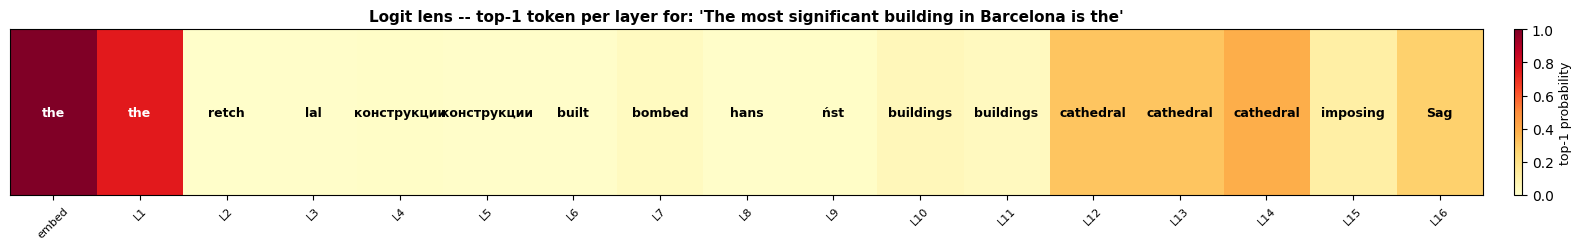

In [39]:
plot_logit_lens_strip(lens_results, PROMPT_LOGIT_LENS, cmap=CMAP)

Three phases are visible across depth: the earliest layers just echo the prompt's own grammar (`is`, copied straight from the input — the embedding layer and layer 1 haven't done any real computation yet), the middle layers are largely noise (subword fragments with low confidence — the model hasn't resolved anything specific), and around layer 12 the surface-level answer `gold` appears — the model has found the topic but not yet the *symbol* being asked for. Only in the last two layers does it snap to the actually-correct token, `Au`, at high confidence. That gap between "found the topic" (layer 12) and "found the answer" (layer 15-16) is exactly the kind of resolution-in-depth pattern a logit lens is built to expose.

# Summary and conclusions

In this notebook we:

1. Mapped every activation capture point used in this chapter to its real path inside `LlamaForCausalLM`, and confirmed in code (not just in prose) that `layer.mlp` and `layer.mlp.down_proj`'s output are the exact same tensor, and that `layer.self_attn` returns a tuple.
2. Compared the `.mlp` submodule of `Llama-3.2-1B` against `Qwen/Qwen3.5-0.8B-Base`, loaded architecture-only, to show the GLU gate/up/down structure survives across model families even as the wrapping class name changes.
3. Built token x neuron and layer x neuron heatmaps with our local, standalone activation-capture and heatmap functions (`get_prompt_activations`, `visualize_prompt_heatmap`, `visualize_prompt_layer_heatmap`), and ran into a real artifact along the way — the BOS token's outsized activations — instead of a synthetic textbook example.
4. Extended the single-panel heatmap into a three-panel `gate_proj | up_proj | down_proj_input` figure to make the GLU gating mechanism from Chapter 5 visible on real activations, in the same three-panel layout that returns in Chapter 11 for the bias-path heatmap.
5. Implemented a logit lens from scratch — projecting every layer's hidden state through the model's own final norm and `lm_head` — and watched a single prediction resolve from generic, to topically-related-but-wrong, to correct, across depth.

### Where this goes next

- **Try a different `LAYER_INDEX`**: the heatmaps and the GLU panel both read this variable — pushing it toward layer 0 or layer 15 changes which pattern dominates.
- **Try a different `PROMPT_LOGIT_LENS`**: factual-recall prompts ("The capital of France is", "The author of Romeo and Juliet is William") tend to produce the clearest resolution curves; open-ended prompts usually don't resolve as cleanly.